### References

https://github.com/gabrielziegler3/xgboost-multiclass-multilabel/blob/master/xgboost-multiclass/multiclass-frog-classification.ipynb


In [96]:
import os

import mlflow
import mlflow.xgboost
import mlflow.sklearn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.feature_selection import mutual_info_regression
import plotly

from sklearn.model_selection import train_test_split
from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
from matplotlib import pyplot

In [97]:
not_use_cols = ['date']
attr_cols = ['open', 'high', 'low', 'close', 'volume', 'average', 'barCount']
h1s = ['h1s_high_max', 'h1s_low_min', 'h1s_barCount_sum', 'h1s_volume_sum', 'h1s_average_avg' ]
h2s = ['h2s_high_max', 'h2s_low_min', 'h2s_barCount_sum', 'h2s_volume_sum', 'h2s_average_avg' ]
h3s = ['h3s_high_max', 'h3s_low_min', 'h3s_barCount_sum', 'h3s_volume_sum', 'h3s_average_avg' ]
h4s = ['h4s_high_max', 'h4s_low_min', 'h4s_barCount_sum', 'h4s_volume_sum', 'h4s_average_avg' ]
hist_5_cols = ['h5s_high_max',  'h5s_low_min',  'h5s_barCount_sum',  'h5s_volume_sum', 'h5s_average_avg']
hist_10_cols= ['h10s_high_max', 'h10s_low_min', 'h10s_barCount_sum', 'h10s_volume_sum','h10s_average_avg']
hist_15_cols= ['h15s_high_max', 'h15s_low_min', 'h15s_barCount_sum', 'h15s_volume_sum','h15s_average_avg']
pred_cols= [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow',  'f5s_25c_arrow' ]
X_cols = [ ]
y_cols = [ ]
X_cols += attr_cols + h1s + h2s + h3s +  h4s
x_cols  = [ 'barCount',          'volume',        'average',
            'h1s_barCount_sum', 'h1s_volume_sum', 'h1s_average_avg' ,
            'h2s_barCount_sum', 'h2s_volume_sum', 'h2s_average_avg' ,
            'h3s_barCount_sum', 'h3s_volume_sum', 'h3s_average_avg',
            'h4s_barCount_sum', 'h4s_volume_sum', 'h4s_average_avg'  ]
y_cols += pred_cols

bin_counts = 3
data_file = "./contract-TSLA/All.csv"


## mlflow logging

### [reference page](https://learn.microsoft.com/en-us/azure/machine-learning/how-to-log-view-metrics?tabs=interactive)

In [98]:
mlflow.set_experiment("vol-xgboost")
mlflow.xgboost.autolog()

In [99]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

In [100]:
def load_data():
    _data = pd.read_csv(data_file, low_memory=False)
    _data = _data.dropna()
    print ("size", _data.shape)
    mlflow.log_param("Size", _data.shape)
    mlflow.log_param("X cols", X_cols)
    mlflow.log_param("y col",  y_cols[1:])
  #  _data = _data.head(1000000)
    return _data

# Code

## load data / split data

In [101]:
%%time
data = load_data()
X = data[X_cols]
y = data [y_cols [1:]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
msg = f"Train {X_train.shape},{y_train.shape}, Test {X_test.shape}, {y_test.shape}"
print (msg)

size (3489404, 53)
Train (2442582, 27),(2442582, 4), Test (1046822, 27), (1046822, 4)
CPU times: user 27.6 s, sys: 4.9 s, total: 32.5 s
Wall time: 33.2 s


## Scale Data

In [102]:
# Standard Scaled X Prediction
scalar = StandardScaler()
scalar.fit(X_train)
X_train = pd.DataFrame(scalar.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns)
#x_train = scalar.transform(x_train)
#x_test = scalar.transform(x_test)


In [103]:
# XGB Parameters

#  https://xgboost.readthedocs.io/en/stable/parameter.html
params2 = {
        'objective': 'multi:softprob',
        'enable_categorical': False,
        'eval_metric': 'merror',  # mlogloss or merror,
        # 'eval_metric': 'multi:softprob'
}
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 2,
        # 'objective': 'validation:accuracy',
        'objective': 'multi:softprob',
        'num_class': bin_counts,
        # 'objective': 'binary:logistic',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        #'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001,  # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0,  # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0,  # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03,  # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05,  # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        # 'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }

In [104]:
# fig, ax = plt.subplots()
#sns.set(rc={'figure.figsize': (12, 9)})
# x_train.plot.hist(alpha=0.5)
#ax = x_train.hist()
# x_train.hist()
# fig = ax.get_figure()
#ax.figure.savefig('TrainingHistogram.png')
#mlflow.log_figure(fig, "TrainingHistogram.png")
# plt.show()
#data2 = data [x_cols + y_cols ]
#data2.plot.hist();
#corr = data2.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.set(rc={'figure.figsize':(66,48)})
#sns.heatmap(corr, annot=True)


In [105]:
#df = data.head(1000)
#plt.matshow(df.corr())
#corr = df.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.heatmap(corr, annot=True)


## Create XGB Model

In [106]:
#Y_cols = [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow',  'f5s_25c_arrow']

xgb_f10 = XGBClassifier(**params2)
xgb_f15 = XGBClassifier(**params2)
xgb_f20 = XGBClassifier(**params2)
xgb_f25 = XGBClassifier(**params2)

#print(xgb.get_xgb_params())
#mlflow.log_param('xgb_params', xgb.get_xgb_params())
#mlflow.xgboost.autolog()


In [107]:
y_train.columns

Index(['f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow', 'f5s_25c_arrow'], dtype='object')

In [108]:
%%time
# Train model & predict
xgb_f10.fit(X_train, y_train['f5s_10c_arrow'])
xgb_f15.fit(X_train, y_train['f5s_15c_arrow'])
xgb_f20.fit(X_train, y_train['f5s_20c_arrow'])
xgb_f25.fit(X_train, y_train['f5s_25c_arrow'])

/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


CPU times: user 3h 9min 14s, sys: 3min 16s, total: 3h 12min 31s
Wall time: 23min 31s


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='merror', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              num_parallel_tree=1, objective='multi:softprob', predictor='auto',
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=None,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [109]:
%%time
y_f10_pred = xgb_f10.predict(X_test)
y_f15_pred = xgb_f15.predict(X_test)
y_f20_pred = xgb_f20.predict(X_test)
y_f25_pred = xgb_f25.predict(X_test)

CPU times: user 25.9 s, sys: 336 ms, total: 26.2 s
Wall time: 2.93 s


In [110]:
#average setting, one of [None, 'micro', 'macro', 'weighted']
# precision, recall, f1, y_true = precision_recall_fscore_support(y_test, y_pred, average='weighted')

ps = precision_score(y_test['f5s_10c_arrow'], y_f10_pred, average='weighted')
rs = recall_score(y_test['f5s_10c_arrow'], y_f10_pred, average='weighted')
ac = accuracy_score(y_test['f5s_10c_arrow'], y_f10_pred)
print(f"f10_accuracy: {round(ac, 3)} f10_precision {round(ps, 3)} f10_recall {round(rs, 3)}")
mlflow.log_metrics({'f10_accuracy': round(ac, 3), 'f10_precision': round(ps, 3), 'f10_recall': round(rs, 3)})


ps = precision_score(y_test['f5s_15c_arrow'], y_f15_pred, average='weighted')
rs = recall_score(y_test['f5s_15c_arrow'], y_f15_pred, average='weighted')
ac = accuracy_score(y_test['f5s_15c_arrow'], y_f15_pred)
print(f"f15_accuracy: {round(ac, 3)} f15_precision {round(ps, 3)} f15_recall {round(rs, 3)}")
mlflow.log_metrics({'f15_accuracy': round(ac, 3), 'f15_precision': round(ps, 3), 'f15_recall': round(rs, 3)})

ps = precision_score(y_test['f5s_20c_arrow'], y_f20_pred, average='weighted')
rs = recall_score(y_test['f5s_20c_arrow'], y_f20_pred, average='weighted')
ac = accuracy_score(y_test['f5s_20c_arrow'], y_f20_pred)
print(f"f20_accuracy: {round(ac, 3)} f20_precision {round(ps, 3)} f20_recall {round(rs, 3)}")
mlflow.log_metrics({'f20_accuracy': round(ac, 3), 'f20_precision': round(ps, 3), 'f20_recall': round(rs, 3)})

ps = precision_score(y_test['f5s_25c_arrow'], y_f25_pred, average='weighted')
rs = recall_score(y_test['f5s_25c_arrow'], y_f25_pred, average='weighted')
ac = accuracy_score(y_test['f5s_25c_arrow'], y_f25_pred)
print(f"f25_accuracy: {round(ac, 3)} f25_precision {round(ps, 3)} f25_recall {round(rs, 3)}")
mlflow.log_metrics({'f25_accuracy': round(ac, 3), 'f25_precision': round(ps, 3), 'f25_recall': round(rs, 3)})


f10_accuracy: 0.683 f10_precision 0.585 f10_recall 0.683
f15_accuracy: 0.822 f15_precision 0.748 f15_recall 0.822
f20_accuracy: 0.897 f20_precision 0.845 f20_recall 0.897
f25_accuracy: 0.937 f25_precision 0.899 f25_recall 0.937


In [111]:
def plot_confusion_matrix(cm, classes, normalized=True, cmap='bone', fmt='.3g'):
    #plt.figure(figsize=[7, 6])
    plt.figure(figsize=[14, 12])
    norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm)
    print(norm_cm)

    arr = [["-"]*len(cm)]*len(cm)
    for j in range(len(cm)):
        for i in range(len(cm[j])):
            arr[j][i] =  f"{cm[j][i]:,d}\n{norm_cm[j][i]:.3f}%"
            print(cm[j][i], arr[j][i])
    print(arr)
    sns.heatmap(norm_cm, annot=arr, annot_kws={'size': 15}, fmt='s', normalize=True)

In [112]:
def plot_confusion_matrix2(_cm, _title):
    plt.figure(figsize=[14, 12])
    disp = ConfusionMatrixDisplay(confusion_matrix=_cm, display_labels=[-1, 0, 1])
    disp.plot(cmap=plt.cm.Paired,  values_format=',')
    fig = disp.ax_.get_figure()
    fig.set_figwidth(12)
    fig.set_figheight(12)
    # print (plt.rcParams.keys())
    plt.rcParams.update({'font.size': 22})
    plt.show()
    mlflow.log_figure(fig, _title)


<Figure size 1008x864 with 0 Axes>

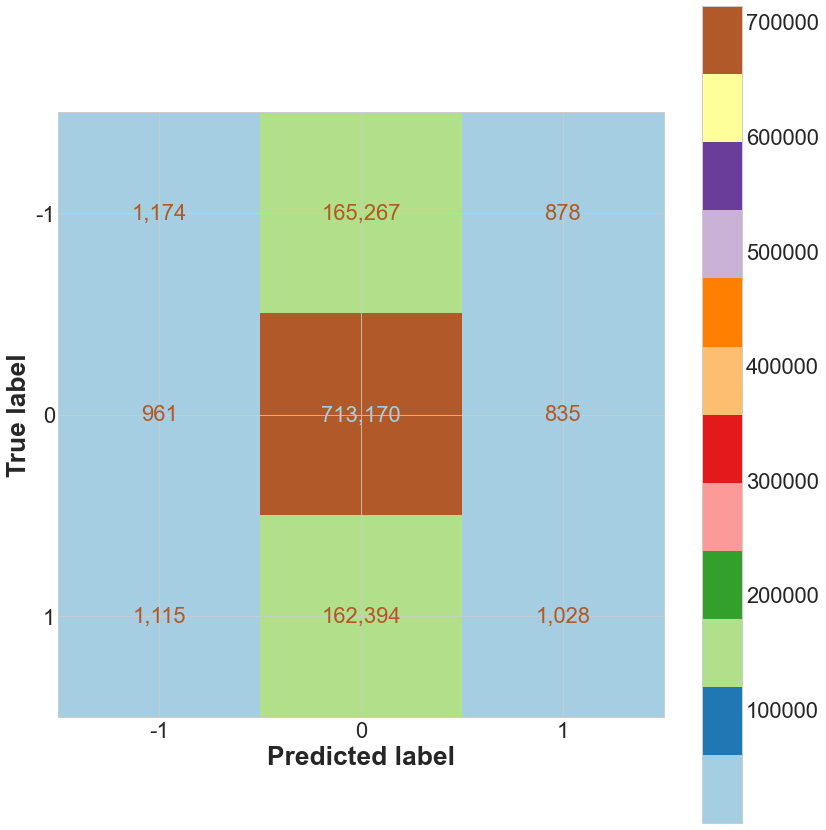

<Figure size 1008x864 with 0 Axes>

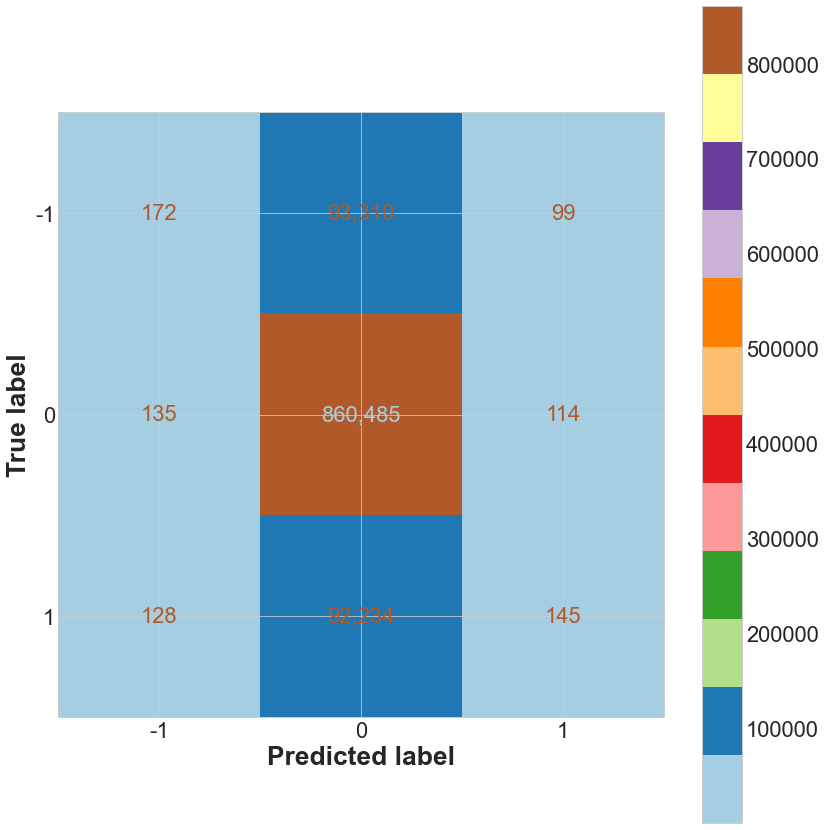

<Figure size 1008x864 with 0 Axes>

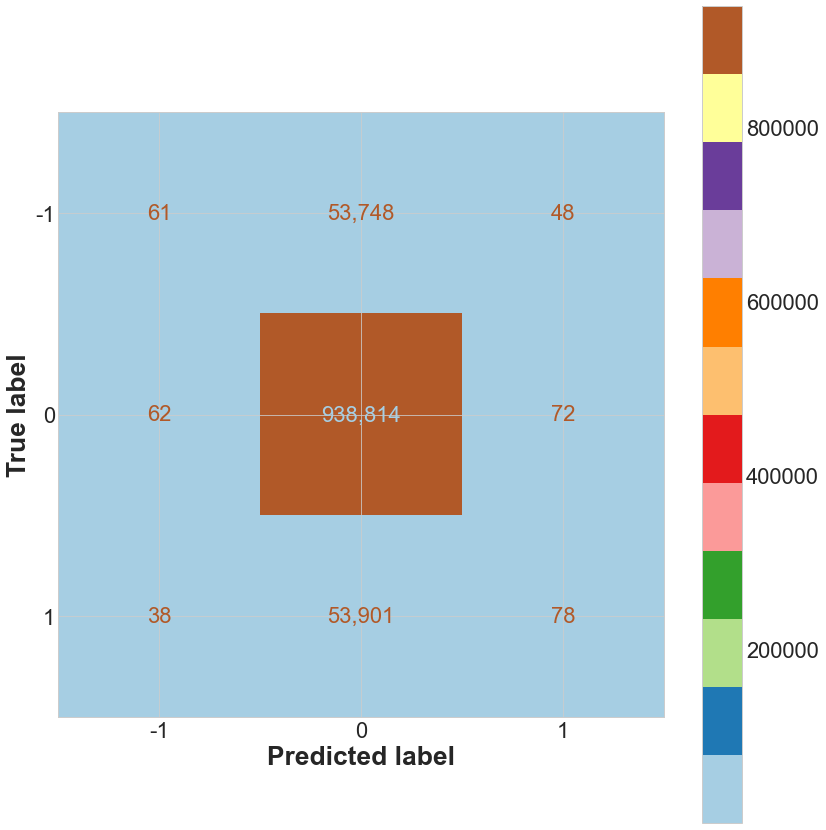

<Figure size 1008x864 with 0 Axes>

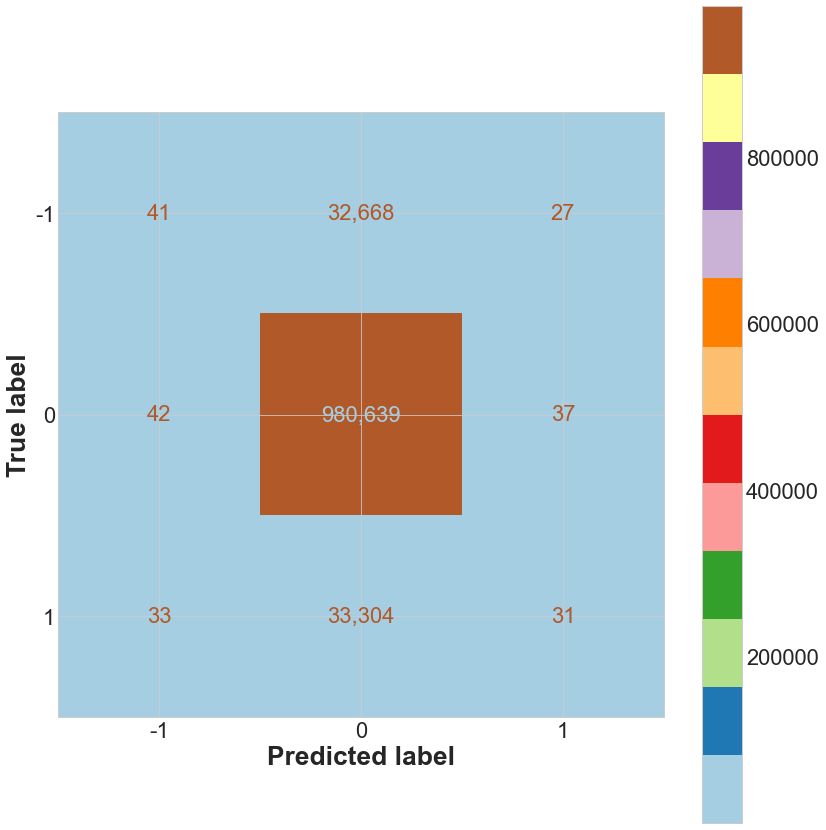

[[  1174 165267    878]
 [   961 713170    835]
 [  1115 162394   1028]]
[[   172  93310     99]
 [   135 860485    114]
 [   128  92234    145]]
[[    61  53748     48]
 [    62 938814     72]
 [    38  53901     78]]
[[    41  32668     27]
 [    42 980639     37]
 [    33  33304     31]]


In [113]:
cm_f10 = confusion_matrix(y_test['f5s_10c_arrow'], y_f10_pred, labels=[-1,0,1])
cm_f15 = confusion_matrix(y_test['f5s_15c_arrow'], y_f15_pred, labels=[-1,0,1])
cm_f20 = confusion_matrix(y_test['f5s_20c_arrow'], y_f20_pred, labels=[-1,0,1])
cm_f25 = confusion_matrix(y_test['f5s_25c_arrow'], y_f25_pred, labels=[-1,0,1])
# norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plot_confusion_matrix2(cm_f10, 'f10_confusion_matrix.png')
plot_confusion_matrix2(cm_f15, 'f15_confusion_matrix.png')
plot_confusion_matrix2(cm_f20, 'f20_confusion_matrix.png')
plot_confusion_matrix2(cm_f25, 'f25_confusion_matrix.png')

print(cm_f10)
print(cm_f15)
print(cm_f20)
print(cm_f25)


In [114]:
print(cm_f10)
print(cm_f15)
print(cm_f20)
print(cm_f25)

[[  1174 165267    878]
 [   961 713170    835]
 [  1115 162394   1028]]
[[   172  93310     99]
 [   135 860485    114]
 [   128  92234    145]]
[[    61  53748     48]
 [    62 938814     72]
 [    38  53901     78]]
[[    41  32668     27]
 [    42 980639     37]
 [    33  33304     31]]


In [115]:
cm_f10_json = {}
cm_f10_json.update({"f10_Confusion_Matrix": cm_f10})
mlflow.log_param("f10_confusion_matrix.json", cm_f10_json)
print(cm_f10_json)

cm_f15_json = {}
cm_f15_json.update({"f15_Confusion_Matrix": cm_f15})
mlflow.log_param("f15_confusion_matrix.json", cm_f15_json)
print(cm_f15_json)

cm_f20_json = {}
cm_f20_json.update({"f20_Confusion_Matrix": cm_f20})
mlflow.log_param("f20_confusion_matrix.json", cm_f20_json)
print(cm_f20_json)

cm_f25_json = {}
cm_f25_json.update({"f25_Confusion_Matrix": cm_f25})
mlflow.log_param("f25_confusion_matrix.json", cm_f25_json)
print(cm_f25_json)

{'f10_Confusion_Matrix': array([[  1174, 165267,    878],
       [   961, 713170,    835],
       [  1115, 162394,   1028]])}
{'f15_Confusion_Matrix': array([[   172,  93310,     99],
       [   135, 860485,    114],
       [   128,  92234,    145]])}
{'f20_Confusion_Matrix': array([[    61,  53748,     48],
       [    62, 938814,     72],
       [    38,  53901,     78]])}
{'f25_Confusion_Matrix': array([[    41,  32668,     27],
       [    42, 980639,     37],
       [    33,  33304,     31]])}


In [116]:
# from mlflow.models.signature import infer_signature
# signature = infer_signature(x_train, xgb.predict(xgb.DMatrix(data=x_train, label=y_train)))
# mlflow.xgboost.log_model(xgb, "model") #, signature=signature)""
#fig, ax = plt.subplots()
#sns.set(rc = {'figure.figsize':(12,9)})
#ns.heatmap(cm, annot=True, cmap="YlGnBu",fmt='d')
#fig.savefig("ConfusionMatrix.png")
#mlflow.log_figure(fig, "ConfusionMatrix.png")
#plt.show()

#sns.heatmap(cm_pct, annot=True, cmap="YlGnBu", fmt=".3f")
#fig.savefig("ConfusionMatrixPct.png")
#mlflow.log_figure(fig, "ConfusionMatrixPct.png")
#plt.show()


# feature_importances = pd.DataFrame(xgb.feature_importances_,index=x_train.columns.tolist(),columns=['importance'])
# feature_importances.sort_values('importance', ascending=False)


In [117]:
def print_fi(xgb, name):
    feature_importance = pd.DataFrame(xgb.feature_importances_,index=X_train.columns.tolist(),columns=['importance'])
    vals = feature_importance.sort_values('importance', ascending=False)
    mlflow.log_param(name, vals.to_string)
    print (name)
    print(vals)


    #_x = pd.Series(xgb.feature_importances_, index=X_train.columns).nlargest(12).plot(kind='barh')
    _x = pyplot.barh(range(len(xgb.feature_importances_)), xgb.feature_importances_, )
    plt.show()
    #mlflow.log_image(image, name)
    return

f10_feature_importance
                  importance
volume              0.108735
h1s_volume_sum      0.072960
high                0.069515
h4s_volume_sum      0.066625
h2s_volume_sum      0.063215
h3s_volume_sum      0.054114
low                 0.043642
h1s_high_max        0.037456
h3s_high_max        0.034009
h3s_low_min         0.032885
h1s_low_min         0.029337
h2s_high_max        0.029228
h3s_barCount_sum    0.029001
h4s_low_min         0.027997
h4s_high_max        0.027522
close               0.026390
h4s_barCount_sum    0.026271
h2s_low_min         0.026254
h2s_barCount_sum    0.025607
average             0.025019
open                0.023858
h1s_barCount_sum    0.023158
h3s_average_avg     0.021422
h4s_average_avg     0.021102
barCount            0.020707
h1s_average_avg     0.018313
h2s_average_avg     0.015661


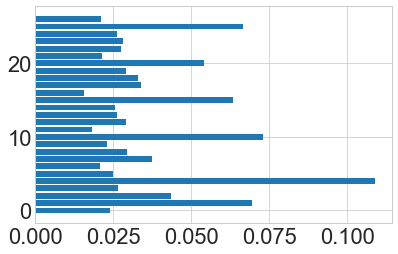

f15_feature_importance
                  importance
volume              0.109626
h1s_volume_sum      0.076528
h3s_volume_sum      0.068492
h2s_volume_sum      0.066199
h4s_volume_sum      0.062443
h1s_high_max        0.047410
high                0.046277
h3s_barCount_sum    0.033554
h4s_high_max        0.033514
h3s_high_max        0.033137
low                 0.030023
h4s_barCount_sum    0.029847
h2s_low_min         0.027926
h4s_low_min         0.027744
h2s_high_max        0.027328
h1s_barCount_sum    0.027172
h2s_barCount_sum    0.027046
open                0.026762
close               0.025674
h1s_low_min         0.024352
h3s_low_min         0.024137
h3s_average_avg     0.022113
barCount            0.021924
h1s_average_avg     0.021216
average             0.021203
h2s_average_avg     0.020299
h4s_average_avg     0.018054


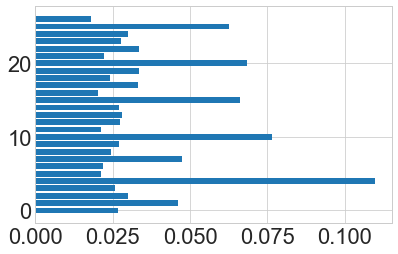

f20_feature_importance
                  importance
volume              0.122412
h1s_volume_sum      0.089813
h3s_volume_sum      0.066980
h4s_volume_sum      0.056734
h2s_volume_sum      0.054804
high                0.042478
h4s_high_max        0.036883
close               0.033796
h1s_high_max        0.033571
h3s_high_max        0.032300
h2s_high_max        0.030926
h4s_barCount_sum    0.028955
h4s_low_min         0.028334
h1s_barCount_sum    0.027872
low                 0.027853
h3s_barCount_sum    0.027428
h3s_low_min         0.026756
h2s_low_min         0.026726
h2s_barCount_sum    0.025779
h1s_low_min         0.023997
average             0.023869
open                0.023653
barCount            0.023316
h2s_average_avg     0.021971
h4s_average_avg     0.021541
h3s_average_avg     0.021115
h1s_average_avg     0.020138


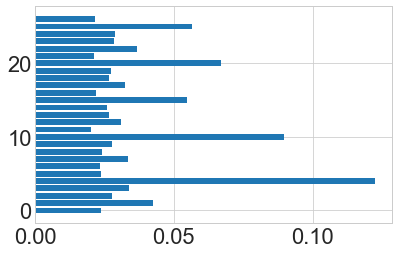

f25_feature_importance
                  importance
volume              0.116305
h1s_volume_sum      0.082935
h3s_volume_sum      0.068911
h2s_volume_sum      0.062474
h4s_volume_sum      0.057833
high                0.042670
h3s_high_max        0.037868
h4s_high_max        0.036362
h2s_high_max        0.036311
h1s_high_max        0.030680
h1s_low_min         0.029242
low                 0.028343
h4s_low_min         0.028199
h4s_barCount_sum    0.027136
h3s_low_min         0.026288
h3s_barCount_sum    0.025991
close               0.025874
h2s_barCount_sum    0.025712
h1s_barCount_sum    0.025276
h2s_low_min         0.025096
h2s_average_avg     0.024752
average             0.023992
h3s_average_avg     0.023276
open                0.023063
barCount            0.022581
h1s_average_avg     0.021944
h4s_average_avg     0.020885


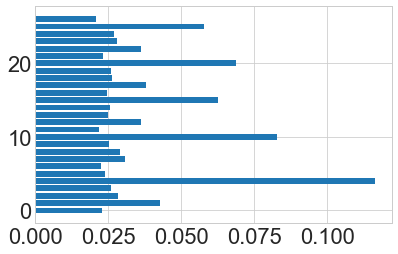

In [118]:
print_fi( xgb_f10, 'f10_feature_importance')
print_fi( xgb_f15, 'f15_feature_importance')
print_fi( xgb_f20, 'f20_feature_importance')
print_fi( xgb_f25, 'f25_feature_importance')

In [119]:
mlflow.end_run()

# ToDo

* add history: h1, h2, h3, h4, h5.  There seems to be no value for >5
* filter time to 9:45 - 15:45
* remove non-full days
* add vix index
* move data to MySQL

DONE:

* Create multiple arrow buckets ('f5s_10c_arrow', 'f5s_20c_arrow') += 'f5s_15c_arrow', 'f5s_25c_arrow', 'f5s_30c_arrow'

In [120]:
print(X_test)

             open      high       low     close    volume   average  barCount  \
0       -0.853241 -0.853782 -0.853194 -0.853746 -0.168424 -0.853485 -0.174003   
1        0.107533  0.107515  0.107482  0.108053  0.549573  0.107629  0.739135   
2        0.702886  0.703216  0.703340  0.703748 -0.238827  0.703392 -0.304451   
3        1.841035  1.845646  1.839687  1.846165  0.018199  1.844418 -0.174003   
4        1.401559  1.402240  1.394585  1.396793  2.022444  1.398901  1.913170   
...           ...       ...       ...       ...       ...       ...       ...   
1046817  1.657090  1.656579  1.657620  1.657100 -0.317052  1.657109 -0.434899   
1046818 -1.091876 -1.087388 -1.094217 -1.090678  0.942376 -1.090398  1.521825   
1046819  2.543550  2.543050  2.543985  2.543561 -0.372927  2.543561 -0.565347   
1046820  1.499846  1.501125  1.495003  1.501307  0.515489  1.497495  0.478239   
1046821  0.549909  0.549385  0.550452  0.549918 -0.372927  0.549921 -0.565347   

         h1s_high_max  h1s_

In [121]:
output = X_test.copy()

In [122]:
cm_f10 = confusion_matrix(y_test['f5s_10c_arrow'], y_f10_pred, labels=[-1,0,1])
cm_f15 = confusion_matrix(y_test['f5s_15c_arrow'], y_f15_pred, labels=[-1,0,1])
cm_f20 = confusion_matrix(y_test['f5s_20c_arrow'], y_f20_pred, labels=[-1,0,1])
cm_f25 = confusion_matrix(y_test['f5s_25c_arrow'], y_f25_pred, labels=[-1,0,1])

In [123]:
print (y_test)
y_test['p_f5s_10c_arrow'] = y_f10_pred
y_test['p_f5s_15c_arrow'] = y_f15_pred
y_test['p_f5s_20c_arrow'] = y_f20_pred
y_test['p_f5s_25c_arrow'] = y_f25_pred
print (y_test)

         f5s_10c_arrow  f5s_15c_arrow  f5s_20c_arrow  f5s_25c_arrow
3495858             -1             -1              0              0
2283955              1              0              0              0
2455068              0              0              0              0
3237640             -1             -1             -1             -1
295339               1              1              1              0
...                ...            ...            ...            ...
667451               0              0              0              0
482525              -1             -1              0              0
811559              -1             -1              0              0
296465              -1              0              0              0
121584               0              0              0              0

[1046822 rows x 4 columns]
         f5s_10c_arrow  f5s_15c_arrow  f5s_20c_arrow  f5s_25c_arrow  \
3495858             -1             -1              0              0   
2283955       

In [124]:
print(X_test.shape)
print(y_test.shape)

to_save = X_test.join(y_test)
to_save.head(100)

#to_save = X_test.copy()
#to_save[ y_test.columns ] = y_test [ y_test.columns ]
print(to_save.shape)

(1046822, 27)
(1046822, 8)
(1046822, 35)


In [125]:
print (y_test.shape)
print (X_test.shape)
print (to_save.shape)

(1046822, 8)
(1046822, 27)
(1046822, 35)


In [126]:
to_save.head()

,open,high,low,close,volume,average,barCount,h1s_high_max,h1s_low_min,h1s_barCount_sum,...,h4s_volume_sum,h4s_average_avg,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow,p_f5s_10c_arrow,p_f5s_15c_arrow,p_f5s_20c_arrow,p_f5s_25c_arrow
0,-0.853241,-0.853782,-0.853194,-0.853746,-0.168424,-0.853485,-0.174003,-0.853192,-0.852090,-0.437738,...,0.068610,-0.848807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.107533,0.107515,0.107482,0.108053,0.549573,0.107629,0.739135,0.107503,0.106961,3.492168,...,-0.354608,0.104465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.702886,0.703216,0.703340,0.703748,-0.238827,0.703392,-0.304451,0.703541,0.701196,1.396218,...,1.260930,0.699760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.841035,1.845646,1.839687,1.846165,0.018199,1.844418,-0.174003,1.845624,1.838134,0.741234,...,0.192026,1.845586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.401559,1.402240,1.394585,1.396793,2.022444,1.398901,1.913170,1.405037,1.400541,1.265221,...,2.394985,1.401149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
to_save.to_csv("test_pred.csv")

In [128]:
y_test.head()

,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow,p_f5s_10c_arrow,p_f5s_15c_arrow,p_f5s_20c_arrow,p_f5s_25c_arrow
3495858,-1,-1,0,0,0,0,0,0
2283955,1,0,0,0,0,0,0,0
2455068,0,0,0,0,0,0,0,0
3237640,-1,-1,-1,-1,0,0,0,0
295339,1,1,1,0,-1,0,0,0


In [129]:
X_test.head()

,open,high,low,close,volume,average,barCount,h1s_high_max,h1s_low_min,h1s_barCount_sum,...,h3s_high_max,h3s_low_min,h3s_barCount_sum,h3s_volume_sum,h3s_average_avg,h4s_high_max,h4s_low_min,h4s_barCount_sum,h4s_volume_sum,h4s_average_avg
0,-0.853241,-0.853782,-0.853194,-0.853746,-0.168424,-0.853485,-0.174003,-0.853192,-0.852090,-0.437738,...,-0.851487,-0.850384,-0.437211,-0.316694,-0.850933,-0.849181,-0.848676,-0.175428,0.068610,-0.848807
1,0.107533,0.107515,0.107482,0.108053,0.549573,0.107629,0.739135,0.107503,0.106961,3.492168,...,0.106213,0.104819,1.655013,1.966237,0.105510,0.103915,0.104907,-0.568249,-0.354608,0.104465
2,0.702886,0.703216,0.703340,0.703748,-0.238827,0.703392,-0.304451,0.703541,0.701196,1.396218,...,0.698834,0.699817,-0.437211,-0.199464,0.699345,0.700461,0.699224,1.788680,1.260930,0.699760
3,1.841035,1.845646,1.839687,1.846165,0.018199,1.844418,-0.174003,1.845624,1.838134,0.741234,...,1.843638,1.844592,-0.437211,-0.316694,1.844118,1.847316,1.844773,0.479275,0.192026,1.845586
4,1.401559,1.402240,1.394585,1.396793,2.022444,1.398901,1.913170,1.405037,1.400541,1.265221,...,1.405611,1.403934,-0.175683,0.378908,1.405518,1.404512,1.397457,0.479275,2.394985,1.401149
